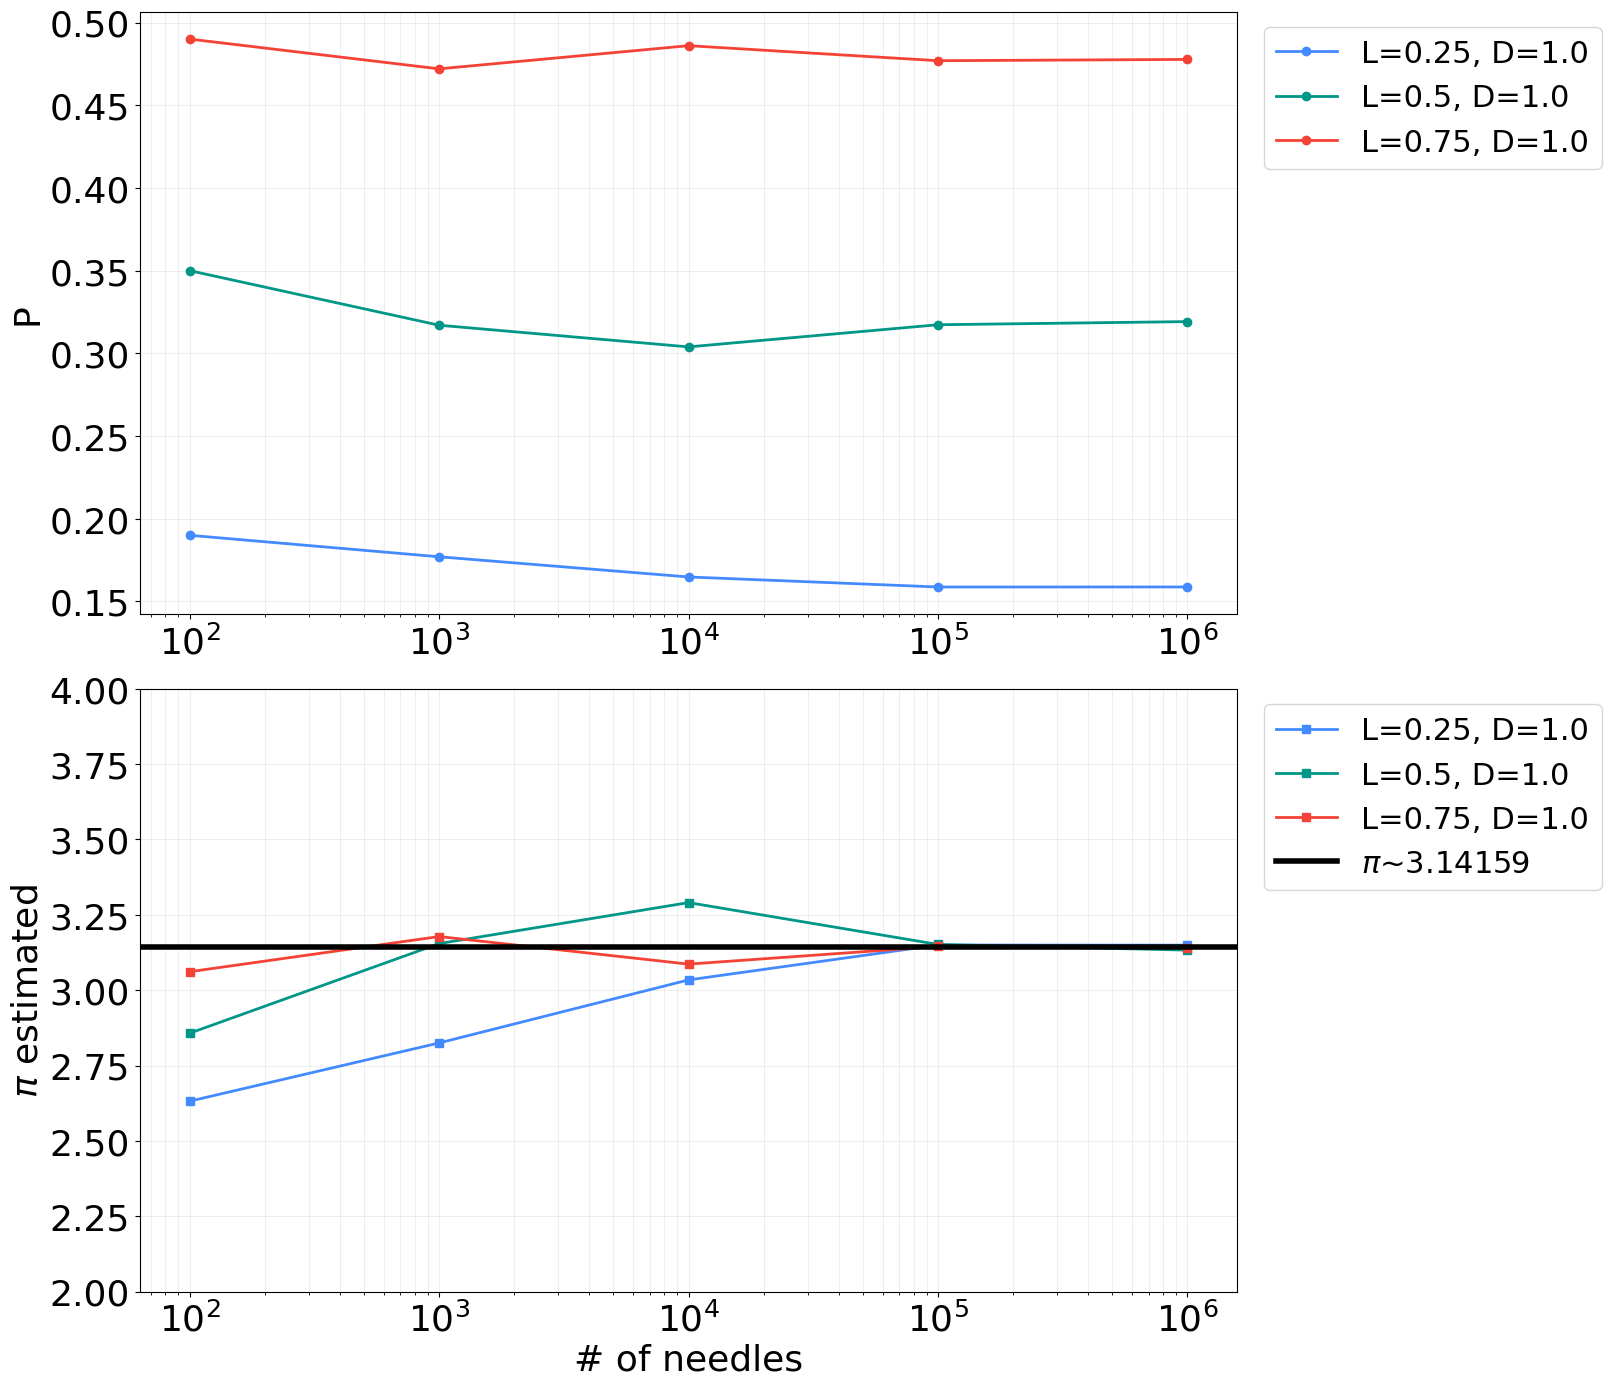


Convergence of Pi Estimates:
      N  Pi_L=0.25, D=1.0  Pi_L=0.5, D=1.0  Pi_L=0.75, D=1.0
    100          2.631579         2.857143          3.061224
   1000          2.824859         3.154574          3.177966
  10000          3.033981         3.290556          3.086420
 100000          3.149805         3.151691          3.145182
1000000          3.149348         3.132911          3.140039


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_buffon_concentric(L, D, num_needles):
    # 1. random center position (r) 
    # an infinite sheet with uniform widths D
    # pick a large radius R 
    # drop the center r within +/- D/2 of the radius
    R_target = 100.0 * D  # large R to approximate the infinite sheet 
    r = np.random.uniform(R_target - D/2, R_target + D/2, num_needles)
    
    # 2. random orientation angle
    # theta is the angle between the radial vector and the needle
    theta = np.random.uniform(0, np.pi, num_needles)
    
    # 3. distances from origin to the two tips (d1, d2)
    # use the law of cosines derived in the analytical section
    d1 = np.sqrt(r**2 + r*L*np.cos(theta) + (L**2)/4)
    d2 = np.sqrt(r**2 - r*L*np.cos(theta) + (L**2)/4)
    
    # 4. crossing condition
    # the needle crosses the circle only if one of the tips is inside and the other is outside
    # mathematically: (d1 > R and d2 < R) or (d1 < R and d2 > R)
    crossings = np.sum(((d1 > R_target) & (d2 < R_target)) | ((d1 < R_target) & (d2 > R_target)))
    
    prob_est = crossings / num_needles
    pi_est = (2 * L) / (D * prob_est) if prob_est > 0 else 0
    return prob_est, pi_est

cases = [(0.25, 1.0), (0.5, 1.0), (0.75, 1.0)] 
iterations = [10**2, 10**3, 10**4, 10**5, 10**6] 
results = {}

for L, D in cases:
    p_theoretical = (2 * L) / (D * np.pi) 
    probs = []
    pi_estimated = []
    for n in iterations:
        est_p, est_pi = simulate_buffon_concentric(L, D, n)
        probs.append(est_p)
        pi_estimated.append(est_pi)
    results[f"L={L}, D={D}"] = (probs, p_theoretical, pi_estimated, L, D)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))
colors = ['#448aff', '#009688', '#f44336']

for i, (key, (probs, p_theoretical, pi_ests, L, D)) in enumerate(results.items()):
    ax1.plot(iterations, probs, marker='o', linewidth=2, label=f"L={L}, D={D}", color=colors[i])
    ax2.plot(iterations, pi_ests, marker='s', linewidth=2, label=f"L={L}, D={D}", color=colors[i])

ax1.set_xscale('log')
ax1.set_ylabel('P', fontsize=26)
ax1.tick_params(axis='both', which='major', labelsize=26) 
ax1.grid(True, which="both", ls="-", alpha=0.2)
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=22)

ax2.set_xscale('log')
ax2.axhline(y=np.pi, color='black', linestyle='-', linewidth=4, label='$\pi$~3.14159')
ax2.set_ylabel('$\pi$ estimated', fontsize=26)
ax2.set_xlabel('# of needles', fontsize=26)
ax2.tick_params(axis='both', which='major', labelsize=26) 
ax2.set_ylim(2.0, 4) 
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=22)

save_path = "/Users/incisardag/Desktop/buffons_needle_part2.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

df_pi = {"N": iterations}
for label, (_, _, pi_ests, _, _) in results.items():
    df_pi[f"Pi_{label}"] = pi_ests

print("\nConvergence of Pi Estimates:")
print(pd.DataFrame(df_pi).to_string(index=False))